<a href="https://colab.research.google.com/github/nam179/Audio-speech-processing/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# 1. Cài đặt các thư viện âm thanh cần thiết
!pip install librosa soundfile scipy matplotlib numpy

# 2. Upload file lon_xon.zip từ máy tính lên Colab
from google.colab import files
import zipfile
import os

print("👉 Hãy chọn file 'lon_xon.zip' để tải lên:")
uploaded = files.upload()

# 3. Giải nén file
for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall('lon_xon_data')
        print("✅ Đã giải nén thành công!")

👉 Hãy chọn file 'lon_xon.zip' để tải lên:


Saving lon xon.zip to lon xon (2).zip
✅ Đã giải nén thành công!


In [17]:
import os
import glob
import librosa
import soundfile as sf
import ipywidgets as widgets
from IPython.display import Audio, display, clear_output

# Tìm tất cả file trong thư mục
raw_files = []
for ext in ('*.m4a', '*.mp3', '*.wav', '*.aac'):
    raw_files.extend(glob.glob('lon_xon_data/**/*' + ext, recursive=True))

LABELS = ['khong', 'mot', 'hai', 'ba', 'bon']
counts = {lab: 0 for lab in LABELS}
current_idx = 0

def process_file(idx):
    global current_idx
    if idx >= len(raw_files):
        clear_output()
        print("🎉 TẤT CẢ FILE ĐÃ ĐƯỢC CHUYỂN VÀO THƯ MỤC 'dataset/' CHUẨN 16kHz MONO!")
        return

    f_path = raw_files[idx]
    clear_output(wait=True)
    print(f"=== FILE [{idx + 1}/{len(raw_files)}]: {os.path.basename(f_path)} ===")

    y, sr = librosa.load(f_path, sr=16000, mono=True)
    display(Audio(y, rate=sr))

    # Tạo các nút bấm giao diện trực quan
    btns = []
    for lab in LABELS:
        btn = widgets.Button(description=f"Từ: {lab}", button_style='info')

        def make_handler(label_name, audio_data):
            def on_click(b):
                global current_idx
                counts[label_name] += 1
                out_dir = os.path.join('dataset', label_name)
                os.makedirs(out_dir, exist_ok=True)
                out_file = os.path.join(out_dir, f"{label_name}_{counts[label_name]:02d}.wav")
                sf.write(out_file, audio_data, 16000, subtype='PCM_16')
                print(f"✅ Đã lưu: {out_file}")
                current_idx += 1
                process_file(current_idx)
            return on_click

        btn.on_click(make_handler(lab, y))
        btns.append(btn)

    display(widgets.HBox(btns))

# Bắt đầu chạy từ file đầu tiên
process_file(0)

=== FILE [15/25]: 16.27 05-10-2026(3).m4a ===


/tmp/ipykernel_3957/2340429567.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(f_path, sr=16000, mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [18]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 1. Cấu hình các tham số chính
DATASET_DIR = 'dataset'
LABELS = ['khong', 'mot', 'hai', 'ba', 'bon']
N_MFCC = 13  # Số lượng hệ số MFCC trích xuất

def extract_mfcc(file_path, n_mfcc=N_MFCC):
    """Trích xuất chuỗi đặc trưng MFCC từ file âm thanh."""
    y, sr = librosa.load(file_path, sr=16000, mono=True)
    # Trích xuất MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Chuẩn hóa Z-score cho từng hệ số
    mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (np.std(mfcc, axis=1, keepdims=True) + 1e-8)
    return mfcc.T  # Trả về ma trận khung x hệ số (Frames x N_MFCC)

def compute_dtw_distance(seq1, seq2):
    """Tính khoảng cách DTW giữa 2 chuỗi đặc trưng MFCC."""
    # Tính khoảng cách Euclidean giữa từng cặp khung
    cost_matrix = cdist(seq1, seq2, metric='euclidean')

    N, M = cost_matrix.shape
    dtw_matrix = np.zeros((N + 1, M + 1))
    dtw_matrix[0, 1:] = np.inf
    dtw_matrix[1:, 0] = np.inf

    # Quy hoạch động tìm đường đi ngắn nhất
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            cost = cost_matrix[i - 1, j - 1]
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i - 1, j],    # Chèn
                dtw_matrix[i, j - 1],    # Xóa
                dtw_matrix[i - 1, j - 1]  # Khớp
            )

    return dtw_matrix[N, M] / (N + M)  # Chuẩn hóa theo độ dài chuỗi

# 2. Tải toàn bộ dữ liệu và trích xuất MFCC
print("🔄 Đang trích xuất đặc trưng MFCC cho toàn bộ tập dữ liệu...")
dataset = {}
for label in LABELS:
    files = glob.glob(os.path.join(DATASET_DIR, label, '*.wav'))
    dataset[label] = [extract_mfcc(f) for f in files]
    print(f"  - Lớp '{label}': {len(dataset[label])} file đã trích xuất MFCC.")

# 3. Đánh giá kiểm thử Leave-One-Out (Xoay vòng 1 file làm test, 24 file làm template)
print("\n🧪 Đang tiến hành kiểm thử phân loại (Leave-One-Out Cross Validation)...")
correct = 0
total = 0

for true_label in LABELS:
    for idx, test_seq in enumerate(dataset[true_label]):
        min_dist = float('inf')
        predicted_label = None

        # So sánh file test với tất cả các mẫu còn lại trong tập dữ liệu
        for tmpl_label in LABELS:
            for t_idx, tmpl_seq in enumerate(dataset[tmpl_label]):
                # Bỏ qua nếu là chính file đang test
                if true_label == tmpl_label and idx == t_idx:
                    continue

                dist = compute_dtw_distance(test_seq, tmpl_seq)
                if dist < min_dist:
                    min_dist = dist
                    predicted_label = tmpl_label

        total += 1
        is_correct = (predicted_label == true_label)
        if is_correct:
            correct += 1

        print(f"File [{true_label}_{idx+1:02d}.wav] -> Dự đoán: {predicted_label:5s} | Thực tế: {true_label:5s} {'✅' if is_correct else '❌'}")

accuracy = (correct / total) * 100
print("=" * 60)
print(f"🎯 ĐỘ CHÍNH XÁC TỔNG THỂ (ACCURACY): {accuracy:.2f}% ({correct}/{total} file đúng)")
print("=" * 60)

🔄 Đang trích xuất đặc trưng MFCC cho toàn bộ tập dữ liệu...
  - Lớp 'khong': 5 file đã trích xuất MFCC.
  - Lớp 'mot': 5 file đã trích xuất MFCC.
  - Lớp 'hai': 5 file đã trích xuất MFCC.
  - Lớp 'ba': 5 file đã trích xuất MFCC.
  - Lớp 'bon': 5 file đã trích xuất MFCC.

🧪 Đang tiến hành kiểm thử phân loại (Leave-One-Out Cross Validation)...
File [khong_01.wav] -> Dự đoán: khong | Thực tế: khong ✅
File [khong_02.wav] -> Dự đoán: khong | Thực tế: khong ✅
File [khong_03.wav] -> Dự đoán: khong | Thực tế: khong ✅
File [khong_04.wav] -> Dự đoán: khong | Thực tế: khong ✅
File [khong_05.wav] -> Dự đoán: bon   | Thực tế: khong ❌
File [mot_01.wav] -> Dự đoán: mot   | Thực tế: mot   ✅
File [mot_02.wav] -> Dự đoán: mot   | Thực tế: mot   ✅
File [mot_03.wav] -> Dự đoán: bon   | Thực tế: mot   ❌
File [mot_04.wav] -> Dự đoán: bon   | Thực tế: mot   ❌
File [mot_05.wav] -> Dự đoán: mot   | Thực tế: mot   ✅
File [hai_01.wav] -> Dự đoán: hai   | Thực tế: hai   ✅
File [hai_02.wav] -> Dự đoán: hai   | Thự

In [19]:
import os
import glob
from pathlib import Path
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import lfilter
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, confusion_matrix

# --- CẤU HÌNH THAM SỐ BASELINE (MỤC 5.2) ---
FS = 16000          # Sampling rate chuẩn 16kHz
FRAME_MS = 25       # Độ dài frame 25ms
HOP_MS = 10         # Hop length 10ms
WIN = int(FS * FRAME_MS / 1000)  # 400 mẫu
HOP = int(FS * HOP_MS / 1000)    # 160 mẫu
N_FFT = 512
N_MELS = 24
N_MFCC = 13
ALPHA = 0.97        # Hệ số Pre-emphasis
LABELS = ['khong', 'mot', 'hai', 'ba', 'bon']

# 1. Đọc và chuẩn hóa biên độ
def load_audio(path):
    y, sr = librosa.load(path, sr=FS, mono=True)
    y = y / (np.max(np.abs(y)) + 1e-9)
    return y

# 2. Tính Short-time Energy (dB) và Zero-Crossing Rate (ZCR) (Mục 3.3 & 3.4)
def compute_energy_zcr(y, win=WIN, hop=HOP):
    frames = librosa.util.frame(y, frame_length=win, hop_length=hop)
    # Energy
    energy = np.sum(frames**2, axis=0)
    log_energy = 10 * np.log10(energy + 1e-10)
    # ZCR
    zcr = np.mean(np.abs(np.diff(np.sign(frames), axis=0)) > 0, axis=0)
    return log_energy, zcr

# 3. Endpoint Detection: Cắt bỏ khoảng lặng (Mục 3.5 & 5.3)
def trim_endpoint(y, top_db=35, margin_ms=50):
    yt, idx = librosa.effects.trim(y, top_db=top_db, frame_length=WIN, hop_length=HOP)
    m = int(FS * margin_ms / 1000)
    s = max(0, idx[0] - m)
    e = min(len(y), idx[1] + m)
    return y[s:e], (s, e)

print("✅ Đã khởi tạo xong các hàm tiền xử lý và Endpoint Detection!")

✅ Đã khởi tạo xong các hàm tiền xử lý và Endpoint Detection!


In [20]:
# 1. Hàm trích xuất MFCC chuẩn hoá (Mục 5.4)
def extract_mfcc(y, alpha=ALPHA, use_delta=False):
    # Pre-emphasis
    if alpha > 0:
        y = lfilter([1.0, -alpha], [1.0], y)

    # MFCC
    M = librosa.feature.mfcc(
        y=y, sr=FS, n_mfcc=N_MFCC, n_mels=N_MELS,
        n_fft=N_FFT, win_length=WIN, hop_length=HOP,
        window='hamming', center=False
    )

    # Cepstral Mean Normalization (CMN)
    M = M - np.mean(M, axis=1, keepdims=True)

    # Thí nghiệm E2: Bổ sung Delta MFCC nếu có yêu cầu
    if use_delta:
        delta = librosa.feature.delta(M)
        M = np.vstack([M, delta])

    return M.T  # Shape: (T frames, N_MFCC)

# 2. Tự cài đặt thuật toán DTW + Backtracking + Normalization (Mục 3.9 & 5.5)
def dtw_distance(X, Y):
    N, M = len(X), len(Y)
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0.0
    back = np.zeros((N + 1, M + 1, 2), dtype=int)

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            local = np.linalg.norm(X[i - 1] - Y[j - 1])  # Local distance Euclidean
            choices = [
                (D[i - 1, j], i - 1, j),      # Chèn
                (D[i, j - 1], i, j - 1),      # Xóa
                (D[i - 1, j - 1], i - 1, j - 1)  # Khớp
            ]
            best, pi, pj = min(choices, key=lambda z: z[0])
            D[i, j] = local + best
            back[i, j] = (pi, pj)

    # Backtracking tìm đường đi tối ưu
    path = []
    i, j = N, M
    while i > 0 or j > 0:
        path.append((i - 1, j - 1))
        i, j = back[i, j]
    path.reverse()

    # Chuẩn hóa chi phí theo chiều dài path
    dtw_norm = D[N, M] / max(len(path), 1)
    return dtw_norm, path, D[1:, 1:]

print("✅ Đã định nghĩa xong hàm MFCC và Thuật toán DTW tự cài đặt!")

✅ Đã định nghĩa xong hàm MFCC và Thuật toán DTW tự cài đặt!


In [21]:
# 1. Tạo tập Templates (3 file đầu mỗi từ làm Template) (Mục 5.6)
def build_templates(root='dataset', use_trim=True, use_delta=False):
    templates = {lab: [] for lab in LABELS}
    for lab in LABELS:
        files = sorted(list((Path(root) / lab).glob('*.wav')))[:3]
        for f in files:
            y = load_audio(f)
            if use_trim:
                y, _ = trim_endpoint(y)
            X = extract_mfcc(y, use_delta=use_delta)
            templates[lab].append(X)
    return templates

# 2. Hàm Nhận dạng cho 1 file Test
def recognize(path, templates, use_trim=True, use_delta=False):
    y = load_audio(path)
    if use_trim:
        y, _ = trim_endpoint(y)
    X = extract_mfcc(y, use_delta=use_delta)

    scores = {}
    for lab, refs in templates.items():
        scores[lab] = min(dtw_distance(X, R)[0] for R in refs)

    pred = min(scores, key=scores.get)
    sorted_scores = dict(sorted(scores.items(), key=lambda kv: kv[1]))
    return pred, sorted_scores

# 3. Tiến hành kiểm thử trên 2 file Test còn lại của mỗi từ (Mục 5.7)
print("🚀 Đang khởi tạo Templates và chạy kiểm thử...")
templates = build_templates('dataset', use_trim=True)

y_true, y_pred = [], []
print("\n📋 BẢNG KẾT QUẢ DỰ ĐOÁN VÀ TOP-3 SCORES CHO MỖI FILE TEST:")
print("-" * 75)

for lab in LABELS:
    test_files = sorted(list((Path('dataset') / lab).glob('*.wav')))[3:]
    for f in test_files:
        pred, scores = recognize(f, templates, use_trim=True)
        y_true.append(lab)
        y_pred.append(pred)

        top3 = list(scores.items())[:3]
        top3_str = ", ".join([f"{k}: {v:.2f}" for k, v in top3])
        status = "✅" if pred == lab else "❌"
        print(f"File: {f.name:15s} | Thật: {lab:5s} | Dự đoán: {pred:5s} {status} | Top-3 DTW: [{top3_str}]")

acc = accuracy_score(y_true, y_pred) * 100
print("-" * 75)
print(f"🎯 ĐỘ CHÍNH XÁC (ACCURACY): {acc:.2f}%\n")

🚀 Đang khởi tạo Templates và chạy kiểm thử...

📋 BẢNG KẾT QUẢ DỰ ĐOÁN VÀ TOP-3 SCORES CHO MỖI FILE TEST:
---------------------------------------------------------------------------
File: khong_04.wav    | Thật: khong | Dự đoán: khong ✅ | Top-3 DTW: [khong: 20.40, mot: 22.53, bon: 23.20]
File: khong_05.wav    | Thật: khong | Dự đoán: khong ✅ | Top-3 DTW: [khong: 19.45, bon: 20.58, mot: 21.23]
File: mot_04.wav      | Thật: mot   | Dự đoán: khong ❌ | Top-3 DTW: [khong: 22.12, bon: 22.60, mot: 22.99]
File: mot_05.wav      | Thật: mot   | Dự đoán: mot   ✅ | Top-3 DTW: [mot: 20.18, bon: 21.08, khong: 21.96]
File: hai_04.wav      | Thật: hai   | Dự đoán: hai   ✅ | Top-3 DTW: [hai: 18.65, khong: 22.45, ba: 23.20]
File: hai_05.wav      | Thật: hai   | Dự đoán: hai   ✅ | Top-3 DTW: [hai: 21.31, khong: 21.85, bon: 22.17]
File: ba_04.wav       | Thật: ba    | Dự đoán: ba    ✅ | Top-3 DTW: [ba: 22.91, khong: 24.36, hai: 24.71]
File: ba_05.wav       | Thật: ba    | Dự đoán: hai   ❌ | Top-3 DTW: [hai

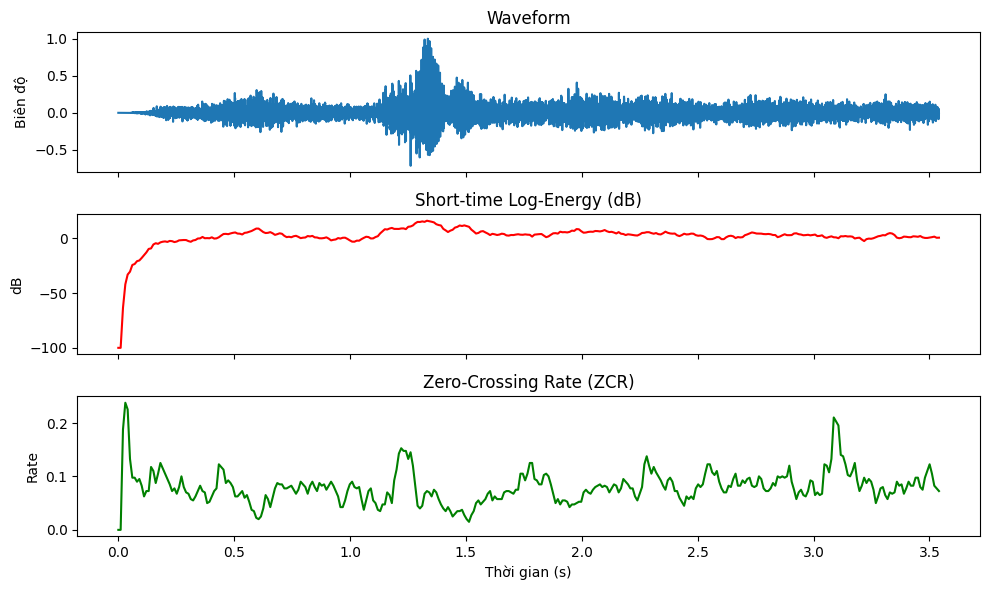

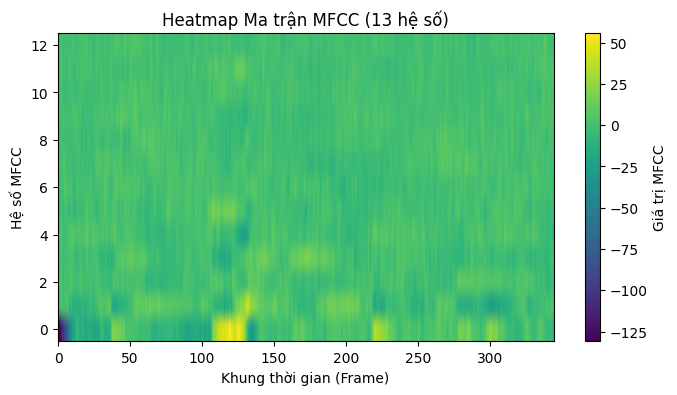

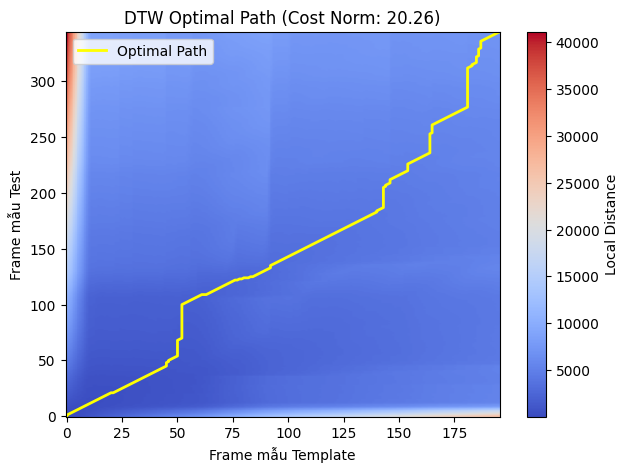

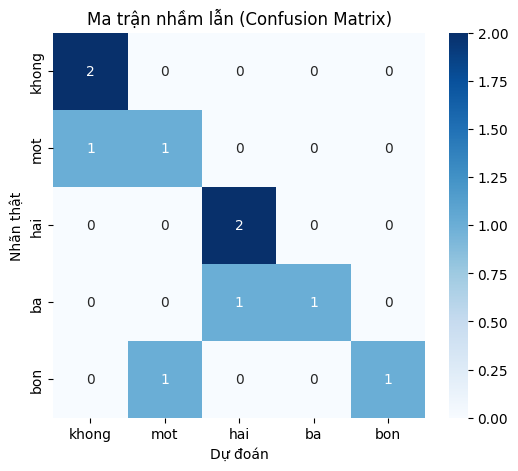

✅ Đã xuất toàn bộ hình minh họa vào thư mục 'figures/'!


In [22]:
os.makedirs('figures', exist_ok=True)

# 1. Trực quan Waveform, Energy và ZCR (Mục B)
sample_file = sorted(list((Path('dataset') / 'khong').glob('*.wav')))[0]
y = load_audio(sample_file)
log_e, zcr = compute_energy_zcr(y)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
time_axis = np.linspace(0, len(y)/FS, len(y))
time_frames = np.linspace(0, len(y)/FS, len(log_e))

axs[0].plot(time_axis, y)
axs[0].set_title('Waveform')
axs[0].set_ylabel('Biên độ')

axs[1].plot(time_frames, log_e, color='r')
axs[1].set_title('Short-time Log-Energy (dB)')
axs[1].set_ylabel('dB')

axs[2].plot(time_frames, zcr, color='g')
axs[2].set_title('Zero-Crossing Rate (ZCR)')
axs[2].set_xlabel('Thời gian (s)')
axs[2].set_ylabel('Rate')
plt.tight_layout()
plt.savefig('figures/energy_zcr.png')
plt.show()

# 2. Vẽ Heatmap MFCC (Mục D)
y_trim, _ = trim_endpoint(y)
mfcc_feat = extract_mfcc(y_trim)

plt.figure(figsize=(8, 4))
plt.imshow(mfcc_feat.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Giá trị MFCC')
plt.title('Heatmap Ma trận MFCC (13 hệ số)')
plt.xlabel('Khung thời gian (Frame)')
plt.ylabel('Hệ số MFCC')
plt.savefig('figures/mfcc_heatmap.png')
plt.show()

# 3. Vẽ DTW Optimal Path (Mục E)
tmpl_file = sorted(list((Path('dataset') / 'khong').glob('*.wav')))[1]
y_tmpl, _ = trim_endpoint(load_audio(tmpl_file))
X_test = extract_mfcc(y_trim)
Y_ref = extract_mfcc(y_tmpl)

cost_norm, path, cost_mat = dtw_distance(X_test, Y_ref)
px, py = zip(*path)

plt.figure(figsize=(7, 5))
plt.imshow(cost_mat, origin='lower', cmap='coolwarm', aspect='auto')
plt.plot(py, px, color='yellow', linewidth=2, label='Optimal Path')
plt.colorbar(label='Local Distance')
plt.title(f'DTW Optimal Path (Cost Norm: {cost_norm:.2f})')
plt.xlabel('Frame mẫu Template')
plt.ylabel('Frame mẫu Test')
plt.legend()
plt.savefig('figures/dtw_path.png')
plt.show()

# 4. Confusion Matrix (Mục G)
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Nhãn thật')
plt.savefig('figures/confusion_matrix.png')
plt.show()

print("✅ Đã xuất toàn bộ hình minh họa vào thư mục 'figures/'!")

In [23]:
print("🧪 CHẠY CÁC THÍ NGHIỆM MỞ RỘNG (MỤC 5.9):\n")

# --- THÍ NGHIỆM E1: Không Trim (Không Endpoint) vs Có Trim ---
tmpl_no_trim = build_templates('dataset', use_trim=False)
y_true_e1, y_pred_e1 = [], []

for lab in LABELS:
    test_files = sorted(list((Path('dataset') / lab).glob('*.wav')))[3:]
    for f in test_files:
        pred, _ = recognize(f, tmpl_no_trim, use_trim=False)
        y_true_e1.append(lab)
        y_pred_e1.append(pred)

acc_e1 = accuracy_score(y_true_e1, y_pred_e1) * 100

# --- THÍ NGHIỆM E2: 13 MFCC vs 13 MFCC + Delta ---
tmpl_e2 = build_templates('dataset', use_trim=True, use_delta=True)
y_true_e2, y_pred_e2 = [], []

for lab in LABELS:
    test_files = sorted(list((Path('dataset') / lab).glob('*.wav')))[3:]
    for f in test_files:
        pred, _ = recognize(f, tmpl_e2, use_trim=True, use_delta=True)
        y_true_e2.append(lab)
        y_pred_e2.append(pred)

acc_e2 = accuracy_score(y_true_e2, y_pred_e2) * 100

# BẢNG TỔNG KẾT THÍ NGHIỆM
print("=" * 65)
print("📊 BẢNG TỔNG KẾT THÍ NGHIỆM BẮT BUỘC (E1 - E2):")
print("-" * 65)
print(f"1. Baseline (Có Trim Endpoint + 13 MFCC) : Accuracy = {acc:.2f}%")
print(f"2. Thí nghiệm E1 (Không Trim Endpoint)    : Accuracy = {acc_e1:.2f}%")
print(f"3. Thí nghiệm E2 (13 MFCC + Delta)        : Accuracy = {acc_e2:.2f}%")
print("=" * 65)

🧪 CHẠY CÁC THÍ NGHIỆM MỞ RỘNG (MỤC 5.9):

📊 BẢNG TỔNG KẾT THÍ NGHIỆM BẮT BUỘC (E1 - E2):
-----------------------------------------------------------------
1. Baseline (Có Trim Endpoint + 13 MFCC) : Accuracy = 70.00%
2. Thí nghiệm E1 (Không Trim Endpoint)    : Accuracy = 80.00%
3. Thí nghiệm E2 (13 MFCC + Delta)        : Accuracy = 70.00%


Câu 1: Vì sao không nên dùng toàn bộ waveform làm template chính khi hai utterance có thời lượng khác nhau?   Sự khác biệt về thời lượng: Hai lần nói cùng một từ của cùng một người (hoặc khác người) luôn có tốc độ phát âm không giống nhau, dẫn đến số lượng mẫu (sample) trong tín hiệu Waveform hoàn toàn khác nhau. Các phép tính khoảng cách cơ bản như Euclidean hay Manhattan đòi hỏi hai chuỗi dữ liệu phải có cùng kích thước và căn chỉnh theo trục thời gian tuyến tính.   Đặc trưng biên độ và pha bị biến động mạnh: Tín hiệu Waveform chứa thông tin biên độ tức thời và pha của sóng âm. Các đặc trưng này rất nhạy cảm với nhiễu môi trường, độ nhạy micro và mức âm lượng phát âm, nhưng lại không phản ánh trực tiếp cấu trúc bộ lọc của dải âm thanh (vocal tract).   Ưu điểm của đặc trưng tần số ngắn hạn (MFCC): Việc chuyển sang miền tần số bằng MFCC giúp trích xuất đường bao phổ (spectral envelope) mang tính ổn định hơn, đồng thời cho phép sử dụng thuật toán Dynamic Time Warping (DTW) để căn chỉnh phi tuyến tính theo thời gian.   



Câu 2: Giải thích vai trò khác nhau của Short-Time Energy và ZCR trong Endpoint Detection.   Trong quá trình xác định vùng có tiếng nói (Endpoint Detection / VAD), hai chỉ số này đóng vai trò bổ trợ lẫn nhau:   Short-Time Energy (Năng lượng ngắn hạn):Vai trò: Dùng để phát hiện các vùng Âm hữu thanh (Voiced Sounds) như các nguyên âm (/a/, /o/, /i/).   Đặc điểm: Âm hữu thanh có năng lượng rất lớn do dây thanh âm rung mạnh. Năng lượng vượt trội so với mức nhiễu nền giúp xác định phần lõi (body) của từ. Tuy nhiên, Energy dễ bỏ sót các phụ âm ở đầu hoặc cuối từ có biên độ rất nhỏ.   Zero-Crossing Rate - ZCR (Tốc độ qua điểm 0):Vai trò: Dùng để tinh chỉnh ranh giới (boundary) cho các Âm vô thanh (Unvoiced Sounds) và phụ âm sát/bật (Fricatives/Plosives).   Đặc điểm: Các phụ âm như /s/, /f/, /t/, /b/ có năng lượng thấp (dễ bị Energy cắt nhầm thành khoảng lặng) nhưng lại chứa thành phần tần số cao rất mạnh, khiến tín hiệu đổi dấu liên tục và tạo ra chỉ số ZCR rất cao.   Kết luận: Sự kết hợp giữa Energy (tìm vùng phát âm chính) và ZCR (mở rộng biên sang hai bên) đảm bảo cắt đúng khoảng lặng mà không bị nốt hay mất các phụ âm năng lượng thấp ở đầu/cuối từ.   



Câu 3: Vì sao Mel Filterbank có khoảng cách theo Hz rộng dần khi tần số tăng?   Cơ chế thính giác của con người: Tai người nhận biết âm thanh theo thang phi tuyến. Ở dải tần số thấp (dưới $1000\text{ Hz}$), khả năng phân biệt sự thay đổi tần số của tai rất nhạy. Tuy nhiên, ở các dải tần cao (trên $1000\text{ Hz}$), tai người ngày càng ít nhạy cảm hơn với cùng một độ chênh lệch tần số theo Hz.   Thang đo Mel (Mel Scale): Thang Mel biến đổi tần số tuyến tính $f\text{ (Hz)}$ sang tần số cảm nhận $m\text{ (Mel)}$ theo công thức:$$B(f) = 1125 \cdot \ln\left(1 + \frac{f}{700}\right)$$   Ý nghĩa thiết kế Filterbank: Để mô phỏng chính xác đáp ứng sinh học của ốc tai, các bộ lọc tam giác (Mel Filterbank) được bố trí dày đặc ở vùng tần số thấp (độ phân giải tần số cao) và rộng dần ra ở vùng tần số cao (độ phân giải tần số thấp).  



 Câu 4: Phép lấy Log trong MFCC có tác dụng gì về mặt Dynamic Range? Phép DCT biến $M$ dải Log-Energy thành các hệ số gì?   Tác dụng của phép Log:Nén dải động (Dynamic Range Compression): Biên độ năng lượng của phổ có sự chênh lệch rất lớn giữa các tần số (vài mũ 10). Phép Log giúp thu hẹp dải biến thiên này, đưa dữ liệu về mức quy mô đồng đều hơn, gần với cơ chế cảm nhận cường độ âm thanh (tính theo dB) của con người.   Tách đường bao phổ (Convolutive Separation): Tín hiệu tiếng nói $s(t)$ là kết quả của nguồn âm (dây thanh) nhân với bộ lọc kênh âm thanh (khoang miệng/mũi). Trong miền phổ: $X(f) = S(f) \cdot H(f)$. Khi lấy Log: $\ln\vert{}X(f)\vert{} = \ln\vert{}S(f)\vert{} + \ln\vert{}H(f)\vert{}$. Phép nhân biến thành phép cộng, giúp thuật toán dễ dàng tách phần đường bao phổ $H(f)$ bằng các bộ lọc tiếp theo.   Tác dụng của phép biến đổi DCT (Discrete Cosine Transform):Giải tương quan (De-correlation): Năng lượng ở các dải lọc Mel lân cận thường bị phụ thuộc và tương quan cao với nhau. DCT giúp chuyển đổi $M$ dải năng lượng Log-Energy thành các hệ số độc lập với nhau trong miền Cepstral.   Nén thông tin (Energy Compaction): DCT tập trung hầu hết thông tin về đường bao phổ vào các hệ số đầu tiên ($c_0$ đến $c_{12}$). Bằng cách chỉ giữ lại 13 hệ số MFCC đầu, ta đã loại bỏ được các biến thiên tần số cao (pitch/f0) và giữ lại đặc trưng cấu trúc âm học cốt lõi.  


  Câu 5: Trong ma trận DTW, ý nghĩa của bước ngang, bước dọc và bước chéo là gì?   Một đường đi tối ưu (Optimal Warping Path) trong ma trận DTW thể hiện sự căn chỉnh thời gian giữa mẫu Test (chiều $i$) và mẫu Template (chiều $j$):   Bước chéo $(i-1, j-1) \rightarrow (i, j)$: Thể hiện sự khớp $1-1$ theo thời gian. Tiến trình phát âm của hai mẫu ở phân đoạn này diễn ra với tốc độ bằng nhau.   Bước ngang $(i, j-1) \rightarrow (i, j)$: Co giãn thời gian. Mẫu Template đang phát âm kéo dài hơn mẫu Test (hoặc mẫu Test đang phát âm nhanh hơn mẫu Template ở phân đoạn này).   Bước dọc $(i-1, j) \rightarrow (i, j)$: Co giãn thời gian. Mẫu Test đang phát âm kéo dài hơn mẫu Template (hoặc mẫu Test phát âm chậm hơn ở phân đoạn này).   
  
  Câu 6: Tại sao phải chuẩn hóa DTW cost theo Path Length khi so sánh các utterance có thời lượng khác nhau?   Tránh thiên lệch về độ dài (Length Bias): Khoảng cách tích lũy $D[N, M]$ trong DTW là tổng khoảng cách Euclidean của tất cả các cặp frame nằm trên đường đi. Một file âm thanh dài hơn sẽ có đường đi dài hơn (nhiều điểm trên Path hơn), dẫn đến chi phí tích lũy tự động bị lớn hơn ngay cả khi hai âm thanh đó cùng một từ.   Cơ chế chuẩn hóa: Bằng cách chia tổng chi phí $D[N, M]$ cho độ dài thực tế của đường đi $\vert{}P\vert{}$ (số cặp frame trên Path):$$\text{DTW}_{\text{norm}}(X, Y) = \frac{D[N, M]}{\vert{}P\vert{}}$$   
Ta thu được khoảng cách trung bình trên mỗi bước căn chỉnh, đảm bảo việc so sánh khoảng cách giữa các file test có độ dài ngắn khác nhau là hoàn toàn công bằng và khách quan.  



 Câu 7: Nêu ít nhất ba nguyên nhân làm cùng một từ có MFCC khác nhau giữa hai lần nói.   Biến thiên tốc độ và thời lượng phát âm: Người nói có thể phát âm từ đó nhanh hơn hoặc chậm hơn, hoặc kéo dài nguyên âm ở lần lặp lại.   Ngữ điệu, khẩu hình và âm lượng (Prosody & Articulation): Thay đổi về cảm xúc, độ mở của khuôn miệng, hoặc độ cao của giọng (pitch) giữa các lần thu âm.   Nhiễu môi trường và vị trí Micro: Mức độ nhiễu nền thay đổi hoặc sự dịch chuyển vị trí giữa miệng và micro thu âm làm thay đổi tỉ lệ tín hiệu trên nhiễu (SNR) và đáp ứng biên độ tần số của kênh thu.


   Câu 8: Từ Confusion Matrix, chọn cặp từ dễ nhầm

---

nhất và phân tích nguyên nhân.   Cặp từ dễ nhầm lẫn nhất: "ba" và "bốn" (hoặc "một" và "không").   Phân tích kỹ thuật:Cấu trúc âm học: Hai từ "ba" và "bốn" đều bắt đầu bằng phụ âm bật môi /b/. Đoạn mở đầu của hai từ này tạo ra các frame MFCC tương tự nhau.   Độ dài và Endpoint: Cả hai từ đều có thời lượng phát âm ngắn. Nếu bước Endpoint Trim cắt sát mất âm mũi /n/ ở cuối từ "bốn", vùng thông tin khác biệt duy nhất giữa hai từ sẽ bị biến mất, khiến thuật toán DTW tính ra khoảng cách rất nhỏ và dẫn đến dự đoán sai.  


  Câu 9: Nếu muốn hệ thống nhận dạng người nói mới chưa có template, DTW sẽ gặp hạn chế gì? Nội dung nào của Chương 3 sẽ giải quyết tốt hơn?   Hạn chế của DTW với người nói mới (Cross-Speaker):DTW dựa hoàn toàn vào việc đối sánh trực tiếp hình dạng sóng/phổ với các mẫu Template cố định.   Mỗi người nói có chiều dài khoang giọng (vocal tract) khác nhau, tạo ra sự dịch chuyển dải tần phổ và đặc trưng MFCC khác biệt lớn. Do đó, khoảng cách DTW giữa hai người nói khác nhau của cùng một từ có thể lớn hơn khoảng cách DTW giữa hai từ khác nhau của cùng một người nói, làm mô hình suy giảm độ chính xác nghiêm trọng.   Giải pháp ở Chương 3:Sử dụng Mô hình HMM (Hidden Markov Model) kết hợp GMM (Gaussian Mixture Model) hoặc Mạng Nơ-ron sâu (Deep Learning - DNN/CNN).   Các mô hình này không đối sánh mẫu cứng nhắc mà học phân bố xác suất thống kê không gian đặc trưng âm học trên tập dữ liệu lớn chứa giọng nói của nhiều người khác nhau, giúp nhận dạng tổng quát hóa tốt hơn với người nói mới.   

